In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [3]:
os.chdir("/u/sebono/conversational_dominance/notebooks/information_exchange_labelling")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance,
    display_colored_sentences
)

/u/sebono/conversational_dominance/notebooks/information_exchange_labelling


/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



### Analysis

In [5]:
import pandas as pd
import re
import numpy as np

noxi_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/Noxi/conversations.csv")
noxi_df.head()

,file_name,file_content
0,S001,"<SPK2> Bonjour. <SPK1> Bonjour, tu <SPK2> Oui...."
1,S002,"<SPK1> Salut, salut! <SPK1> Salut <SPK2> Salut..."
2,S003,<SPK1> Salut! <SPK2> Salut. <SPK1> Tu m'entend...
3,S006,"<SPK1> Oh putain, c'est parti! <SPK1> Ok, alor..."
4,S007,<SPK2> Salut! <SPK2> Salut! <SPK2> On peut com...


In [6]:
file_name = "S001"
dialog = noxi_df[noxi_df['file_name']==file_name]["file_content"][0]

In [7]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

Token indices sequence length is longer than the specified maximum sequence length for this model (8555 > 1024). Running this sequence through the model will result in indexing errors


In [8]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/noxi_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [9]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


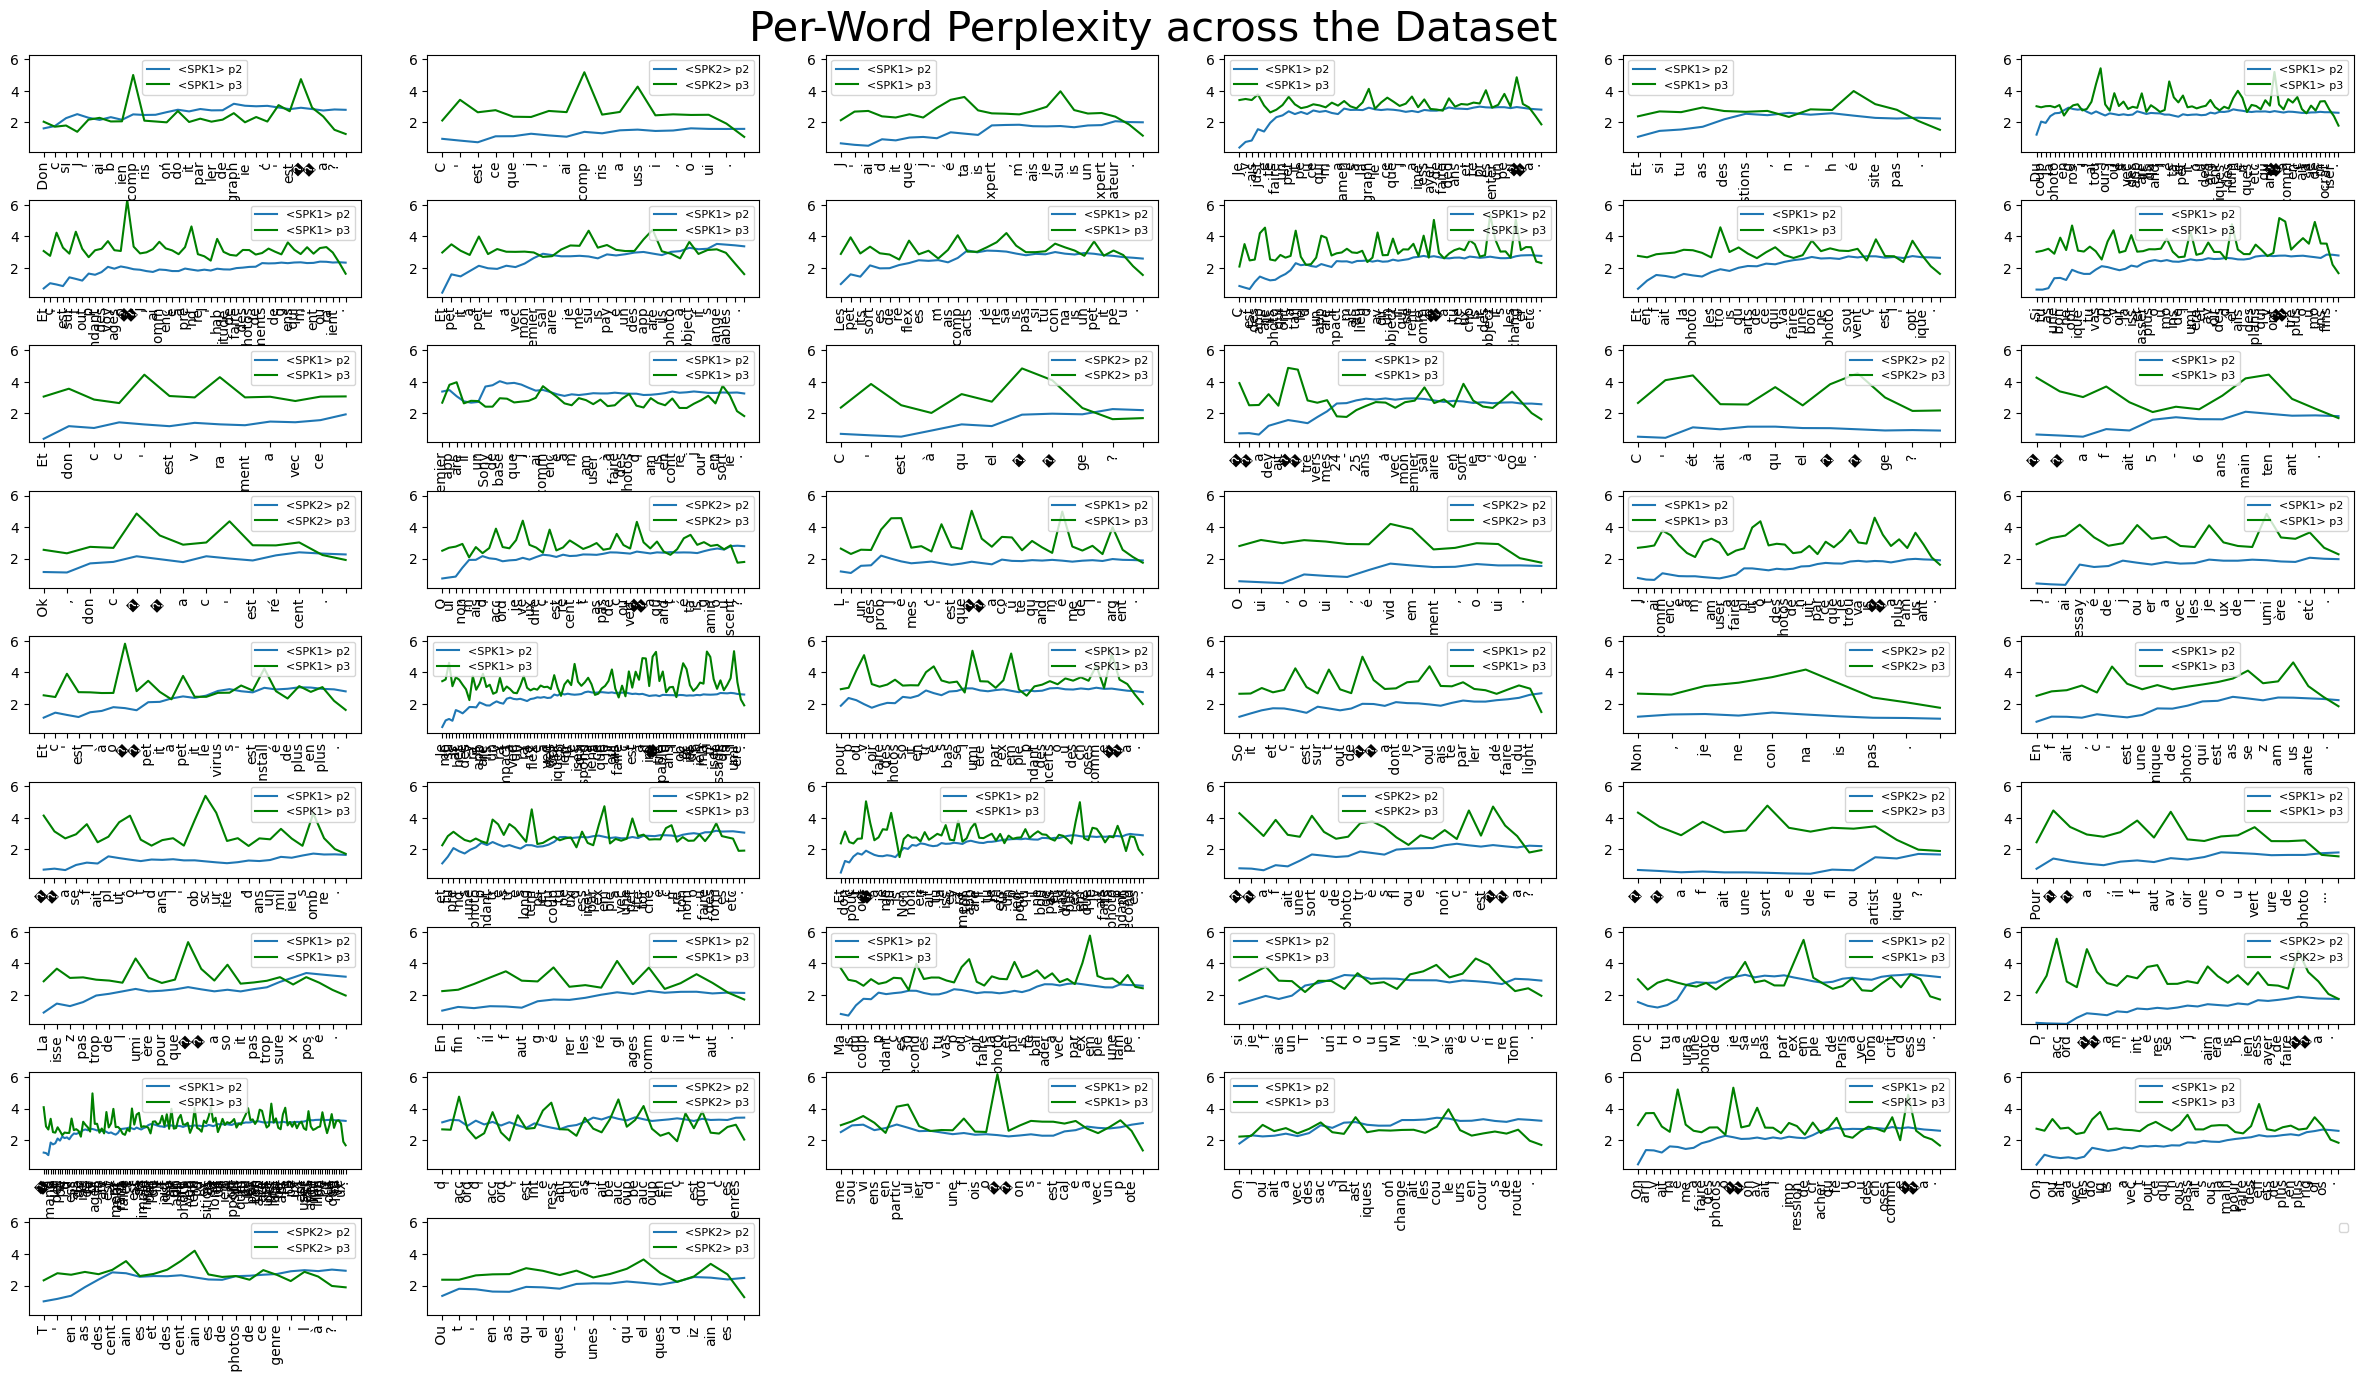

In [10]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p2[:end], filtered_ppl_p3[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [11]:
ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [12]:
np.mean(ppls_p1_spk["<SPK1>"]), np.mean(ppls_p2_spk["<SPK1>"]), np.mean(ppls_p3_spk["<SPK1>"])

(3.0716260035519407, 2.4718837268359626, 3.0062772977770162)

In [13]:
np.mean(ppls_p1_spk["<SPK2>"]), np.mean(ppls_p2_spk["<SPK2>"]), np.mean(ppls_p3_spk["<SPK2>"])

(2.7844104313646327, 2.119573604616997, 3.0720142367022847)

In [14]:
np.mean(ppls_p1_spk['<SPK1>']) > np.mean(ppls_p1_spk['<SPK2>']), np.mean(ppls_p2_spk['<SPK1>']) > np.mean(ppls_p2_spk['<SPK2>']), np.mean(ppls_p3_spk['<SPK1>']) < np.mean(ppls_p3_spk['<SPK2>'])

(True, True, True)

In [15]:
rows, nested = compute_significance(ppls_p2_spk, ['<SPK1>', '<SPK2>'], adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,4021,2459,2.341719e-01,7.167081e-74,7.167081e-74
1,Mann-Whitney U,<SPK1>,<SPK2>,4021,2459,6.353545e+06,6.376182e-83,6.376182e-83
2,T-test,<SPK1>,<SPK2>,4021,2459,1.814091e+01,2.717487e-71,2.717487e-71


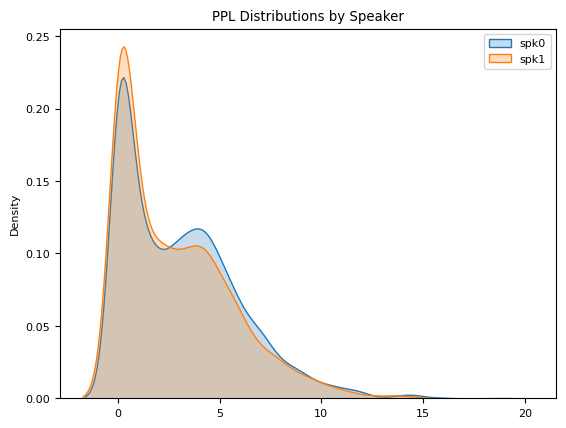

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

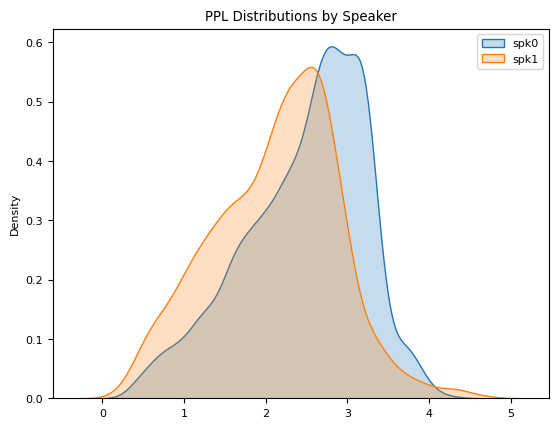

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

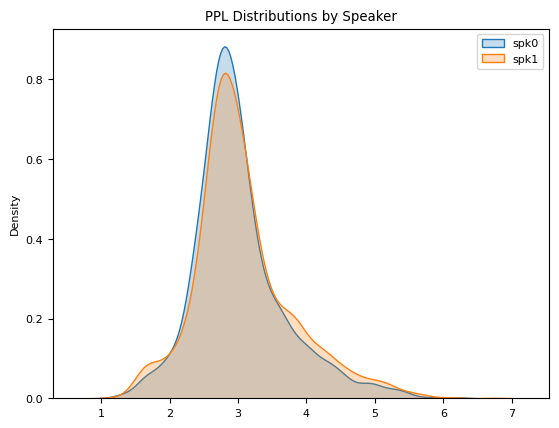

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [19]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

### Per-turn Analysis

In [20]:
per_turn_ppl = pd.DataFrame({"tokens": filtered_tokens_p1})

In [21]:
from itertools import count

# Start from offset
start_index = 0
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

per_turn_ppl["ppl"] = per_turn_ppl["tokens"].apply(assign_indices)

In [22]:
per_turn_ppl["ppl"].iloc[-1][-1], len(filtered_ppl_p3)

(6479, 6480)

In [23]:
np.mean(filtered_ppl_p3[0:8])

1.950896978378296

In [24]:
per_turn_ppl["speaker"] = filtered_matches_p1

In [25]:
per_turn_ppl["p1"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p2"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p3"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

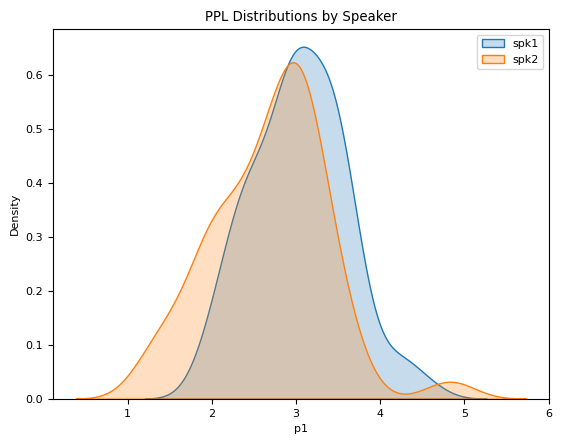

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

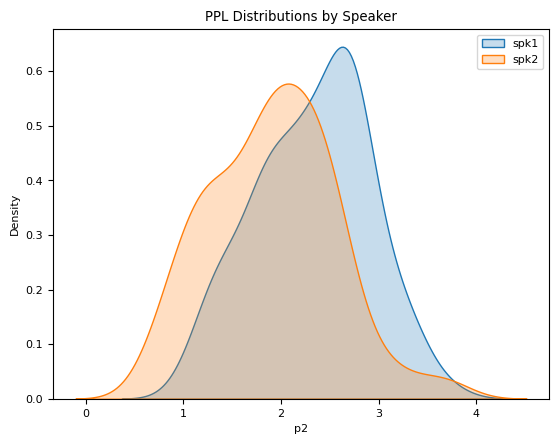

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

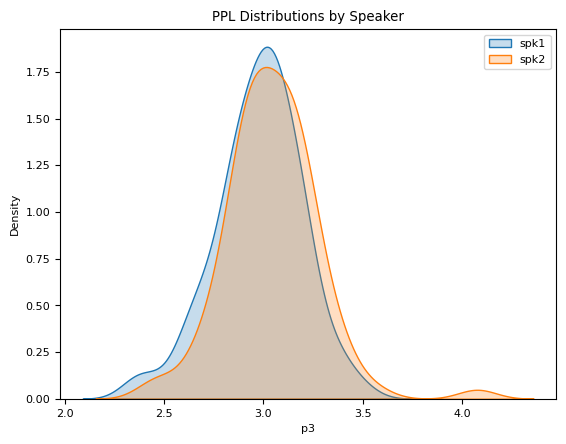

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [29]:
ppls_p1_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p1']})
ppls_p2_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p2']})
ppls_p3_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p3']})

In [30]:
np.mean(ppls_p1_spk["<SPK1>"]), np.mean(ppls_p2_spk["<SPK1>"]), np.mean(ppls_p3_spk["<SPK1>"])

(3.0320895790368807, 2.3202651005077892, 2.9752766505397954)

In [31]:
np.mean(ppls_p1_spk["<SPK2>"]), np.mean(ppls_p2_spk["<SPK2>"]), np.mean(ppls_p3_spk["<SPK2>"])

(2.68698417921392, 1.9052323117260124, 3.0416170973129137)

In [32]:
rows, nested = compute_significance(ppls_p1_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,102,88,0.229501,0.011058,0.011058
1,Mann-Whitney U,<SPK1>,<SPK2>,102,88,5866.000000,0.000268,0.000268
2,T-test,<SPK1>,<SPK2>,102,88,3.781386,0.000216,0.000216


In [33]:
rows, nested = compute_significance(ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,102,88,0.316176,0.000106,0.000106
1,Mann-Whitney U,<SPK1>,<SPK2>,102,88,6216.000000,0.000005,0.000005
2,T-test,<SPK1>,<SPK2>,102,88,4.658785,0.000006,0.000006


In [34]:
rows, nested = compute_significance(ppls_p3_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,102,88,0.152184,0.196550,0.196550
1,Mann-Whitney U,<SPK1>,<SPK2>,102,88,3795.000000,0.066935,0.066935
2,T-test,<SPK1>,<SPK2>,102,88,-2.034255,0.043399,0.043399


In [35]:
per_turn_ppl["dialog"] = per_turn_ppl["tokens"].map(lambda x: " ".join([tokenizer.decode(token, skip_special_tokens=True) for token in x]))

In [36]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,per_turn_ppl)